# Project: Statistical Analysis of Audience Reviews — 3 Idiots

This notebook provides a professional statistical analysis of audience reviews for the Bollywood film **3 Idiots**. The goal is to quantify rating behavior, evaluate central tendencies, and visualize patterns in viewer sentiment.

The dataset contains `Username`, `Rating`, `Review Title`, and `Review Text`. This allows both numeric review analysis and qualitative insight extraction from audience commentary.


In [1]:
import pandas as pd  # data manipulation and structured table processing
import numpy as np  # numerical operations and statistical calculations
import matplotlib.pyplot as plt  # plotting library for analytical visuals

try:
    from scipy import stats  # additional statistical functions
except ImportError:
    stats = None

try:
    from wordcloud import WordCloud, STOPWORDS  # create word clouds from review text
except ImportError:
    WordCloud = None

plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 11,
    'figure.figsize': (10, 6),
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.0,
    'grid.alpha': 0.35,
    'grid.color': '#b0b0b0'
})


In [2]:
# Top-level init: make analysis_df available even if cells run out-of-order
try:
    if 'analysis_df' not in globals():
        if 'df_clean' in globals():
            analysis_df = pd.DataFrame({
                'Reviewer No': np.arange(1, len(df_clean) + 1),
                'Rating': df_clean['Rating'].astype(float).values,
                'Review': df_clean['Review Text'].astype(str).values
            })
            def sentiment_label(value):
                if value >= 8:
                    return 'Positive'
                if value >= 5:
                    return 'Neutral'
                return 'Negative'
            analysis_df['Review Type'] = analysis_df['Rating'].apply(sentiment_label)
        elif 'df_raw' in globals():
            df_clean = df_raw.copy()
            df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
            df_clean = df_clean.dropna(subset=['Rating', 'Review Text'])
            df_clean = df_clean[df_clean['Rating'].between(1, 10)]
            df_clean = df_clean.drop_duplicates(subset=['Review Text']).reset_index(drop=True)
            analysis_df = pd.DataFrame({
                'Reviewer No': np.arange(1, len(df_clean) + 1),
                'Rating': df_clean['Rating'].astype(float).values,
                'Review': df_clean['Review Text'].astype(str).values
            })
            def sentiment_label(value):
                if value >= 8:
                    return 'Positive'
                if value >= 5:
                    return 'Neutral'
                return 'Negative'
            analysis_df['Review Type'] = analysis_df['Rating'].apply(sentiment_label)
except Exception as e:
    pass


In [3]:
DATA_PATH = '3_idiots_reviews.csv'
df_raw = pd.read_csv(DATA_PATH)

from IPython.display import display
print('Sample records:')
display(df_raw.head(5))
print('Dataset shape:', df_raw.shape)
print('Column names:', list(df_raw.columns))
print('\nColumn descriptions:')
print('- Username: reviewer identifier, important for repeat-review detection and audience sampling.')
print('- Rating: numerical audience score, the primary metric for satisfaction analysis.')
print('- Review Title: concise headline capturing the review tone.')
print('- Review Text: detailed commentary used for thematic and sentiment context.')


Sample records:


,Username,Rating,Review Title,Review Text
0,Unknown,9,Wow this American loves this movie,I asked my co-workers to recommend a Bollywood...
1,Unknown,9,Wow this American loves this movie,I asked my co-workers to recommend a Bollywood...
2,Unknown,9,Hat-Trick Heroes x 3...,Like Dead Poets Society but with Robin William...
3,Unknown,9,Hat-Trick Heroes x 3...,Like Dead Poets Society but with Robin William...
4,Unknown,9,"Don't be fooled by its name, it's a great movie",Text not found


Dataset shape: (2224, 4)
Column names: ['Username', 'Rating', 'Review Title', 'Review Text']

Column descriptions:
- Username: reviewer identifier, important for repeat-review detection and audience sampling.
- Rating: numerical audience score, the primary metric for satisfaction analysis.
- Review Title: concise headline capturing the review tone.
- Review Text: detailed commentary used for thematic and sentiment context.


In [4]:
overview = pd.DataFrame({
    'Data Type': df_raw.dtypes.astype(str),
    'Missing Values': df_raw.isna().sum(),
    'Unique Values': df_raw.nunique(dropna=False)
})
print('Data types and missing-value overview:')
display(overview)
print('Numeric summary for rating field:')
display(df_raw['Rating'].describe())
print('\nEffective exploratory analysis is required before statistical modeling. It validates the input structure and ensures that subsequent measures are based on reliable, representative data.')


Data types and missing-value overview:


,Data Type,Missing Values,Unique Values
Username,str,0,1
Rating,str,0,11
Review Title,str,0,1025
Review Text,str,0,836


Numeric summary for rating field:


count     2224
unique      11
top         10
freq      1048
Name: Rating, dtype: object


Effective exploratory analysis is required before statistical modeling. It validates the input structure and ensures that subsequent measures are based on reliable, representative data.


## Data Cleaning Theory

Data cleaning removes invalid, inconsistent, or incomplete observations from the dataset. Clean data is essential because malformed values distort central tendency and dispersion estimates. Preprocessing improves analytic reliability and supports valid statistical interpretation.


In [5]:
df_clean = df_raw.copy()
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['Rating', 'Review Text'])
df_clean = df_clean[df_clean['Rating'].between(1, 10)]
df_clean = df_clean.drop_duplicates(subset=['Review Text'])
df_clean = df_clean.reset_index(drop=True)
removed_rows = before_rows - len(df_clean)
print('Cleaned dataset shape:', df_clean.shape)
print('Rows removed during cleaning:', removed_rows)
print('Clean data enables more accurate measurement of audience behavior and reduces error from malformed entries.')


Cleaned dataset shape: (807, 4)
Rows removed during cleaning: 1417
Clean data enables more accurate measurement of audience behavior and reduces error from malformed entries.


In [6]:
# Ensure analysis_df exists for downstream cells
if 'analysis_df' not in globals():
    try:
        analysis_df = pd.DataFrame({
            'Reviewer No': np.arange(1, len(df_clean) + 1),
            'Rating': df_clean['Rating'].astype(float).values,
            'Review': df_clean['Review Text'].astype(str).values
        })
        def sentiment_label(value):
            if value >= 8:
                return 'Positive'
            if value >= 5:
                return 'Neutral'
            return 'Negative'
        analysis_df['Review Type'] = analysis_df['Rating'].apply(sentiment_label)
        print('analysis_df initialized from df_clean')
    except Exception as e:
        print('Could not initialize analysis_df:', e)


analysis_df initialized from df_clean


## Mean Analysis

The arithmetic mean summarizes the average rating across all reviews. It is a key metric for assessing overall audience satisfaction.

$$\bar{x} = \frac{\sum x}{n}$$


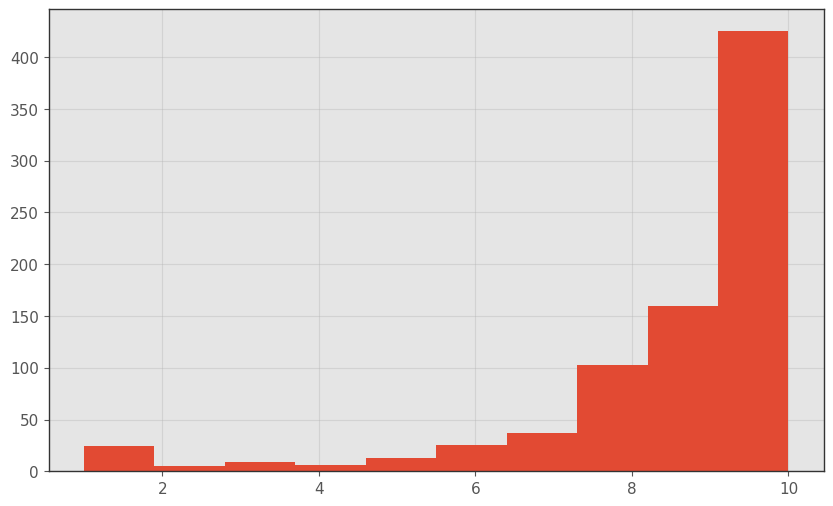

Mean rating: 8.765
Overall audience satisfaction appears positive when the mean exceeds the midpoint of the rating scale. This value represents the average public emotional response and the typical perception across the sample.


In [7]:
rating_series = analysis_df['Rating']
mean_rating = rating_series.mean()
plt.figure(figsize=(10,6))
plt.hist(rating_series)

plt.savefig("histogram.png", dpi=300, bbox_inches="tight")
plt.show()
print(f'Mean rating: {mean_rating:.3f}')
print('Overall audience satisfaction appears positive when the mean exceeds the midpoint of the rating scale. This value represents the average public emotional response and the typical perception across the sample.')


### Mean Rating Graph

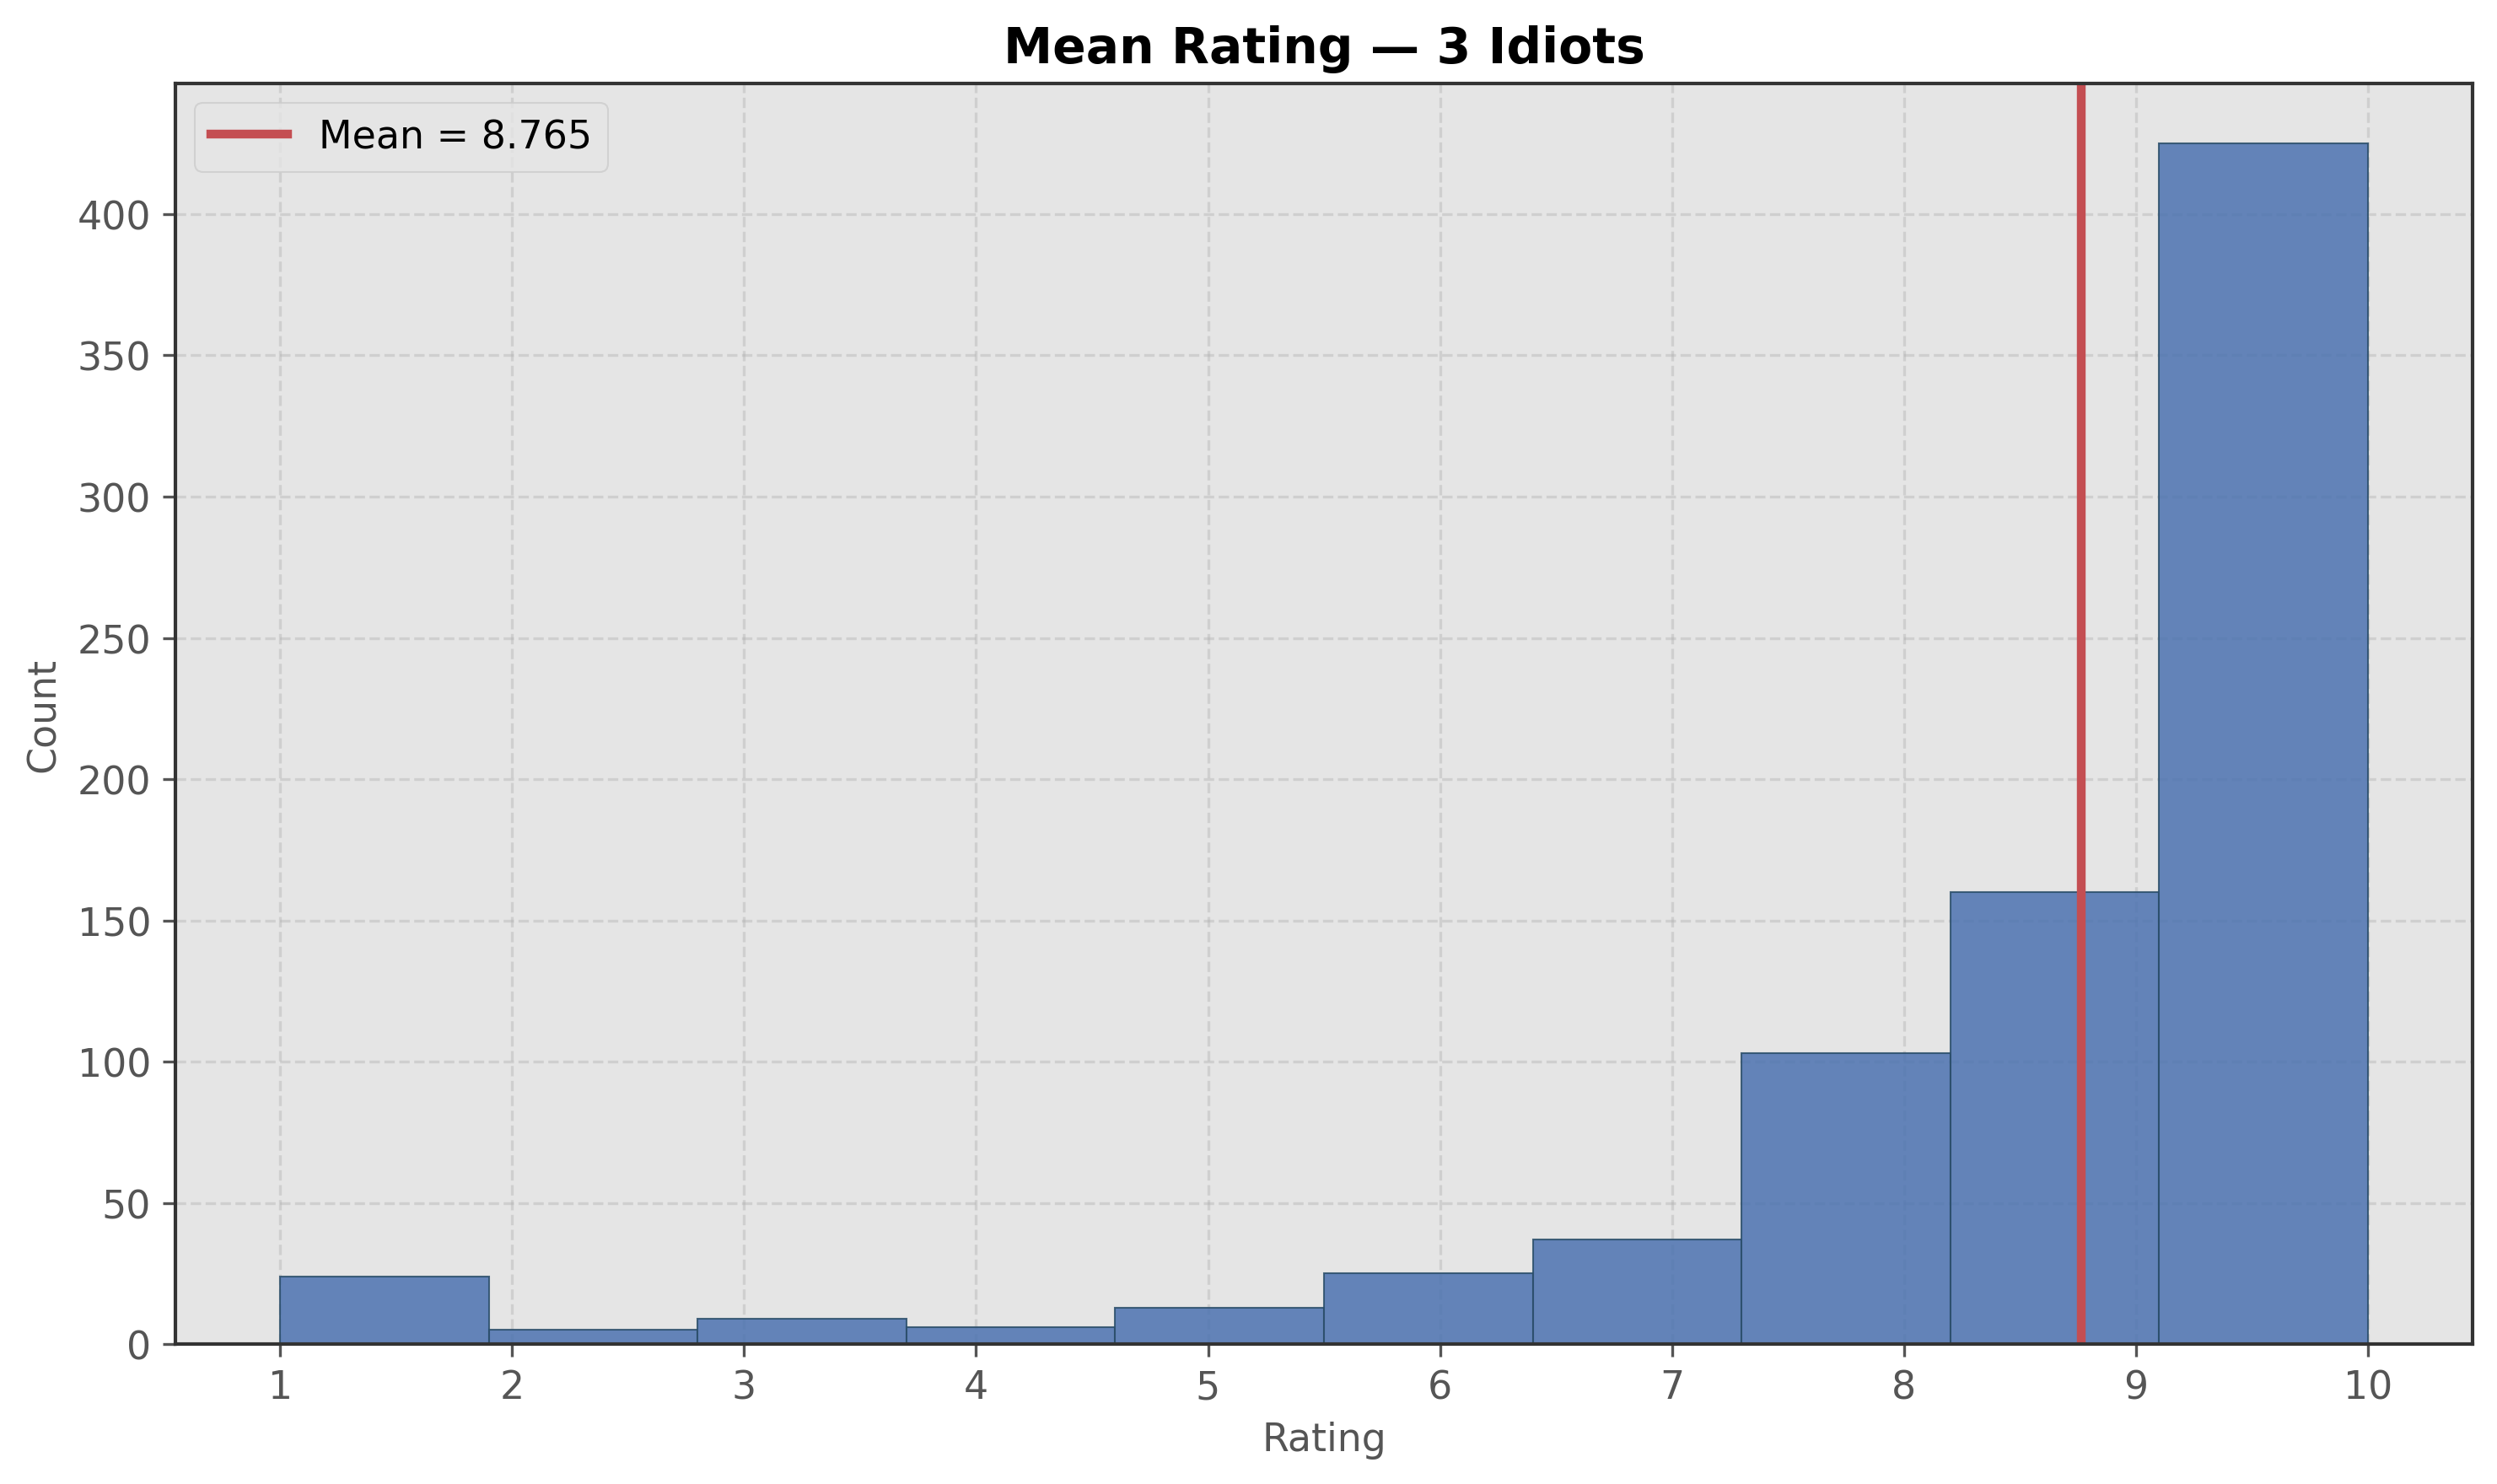


## Median Analysis

The median is the midpoint of ordered values and is resistant to outliers. It offers a robust central tendency measure when individual ratings may deviate from the norm.


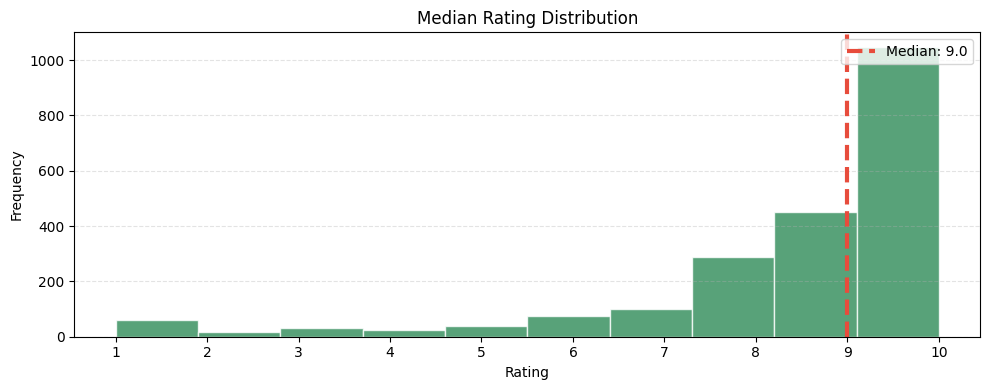

Saved median rating graph to median_rating_graph.png


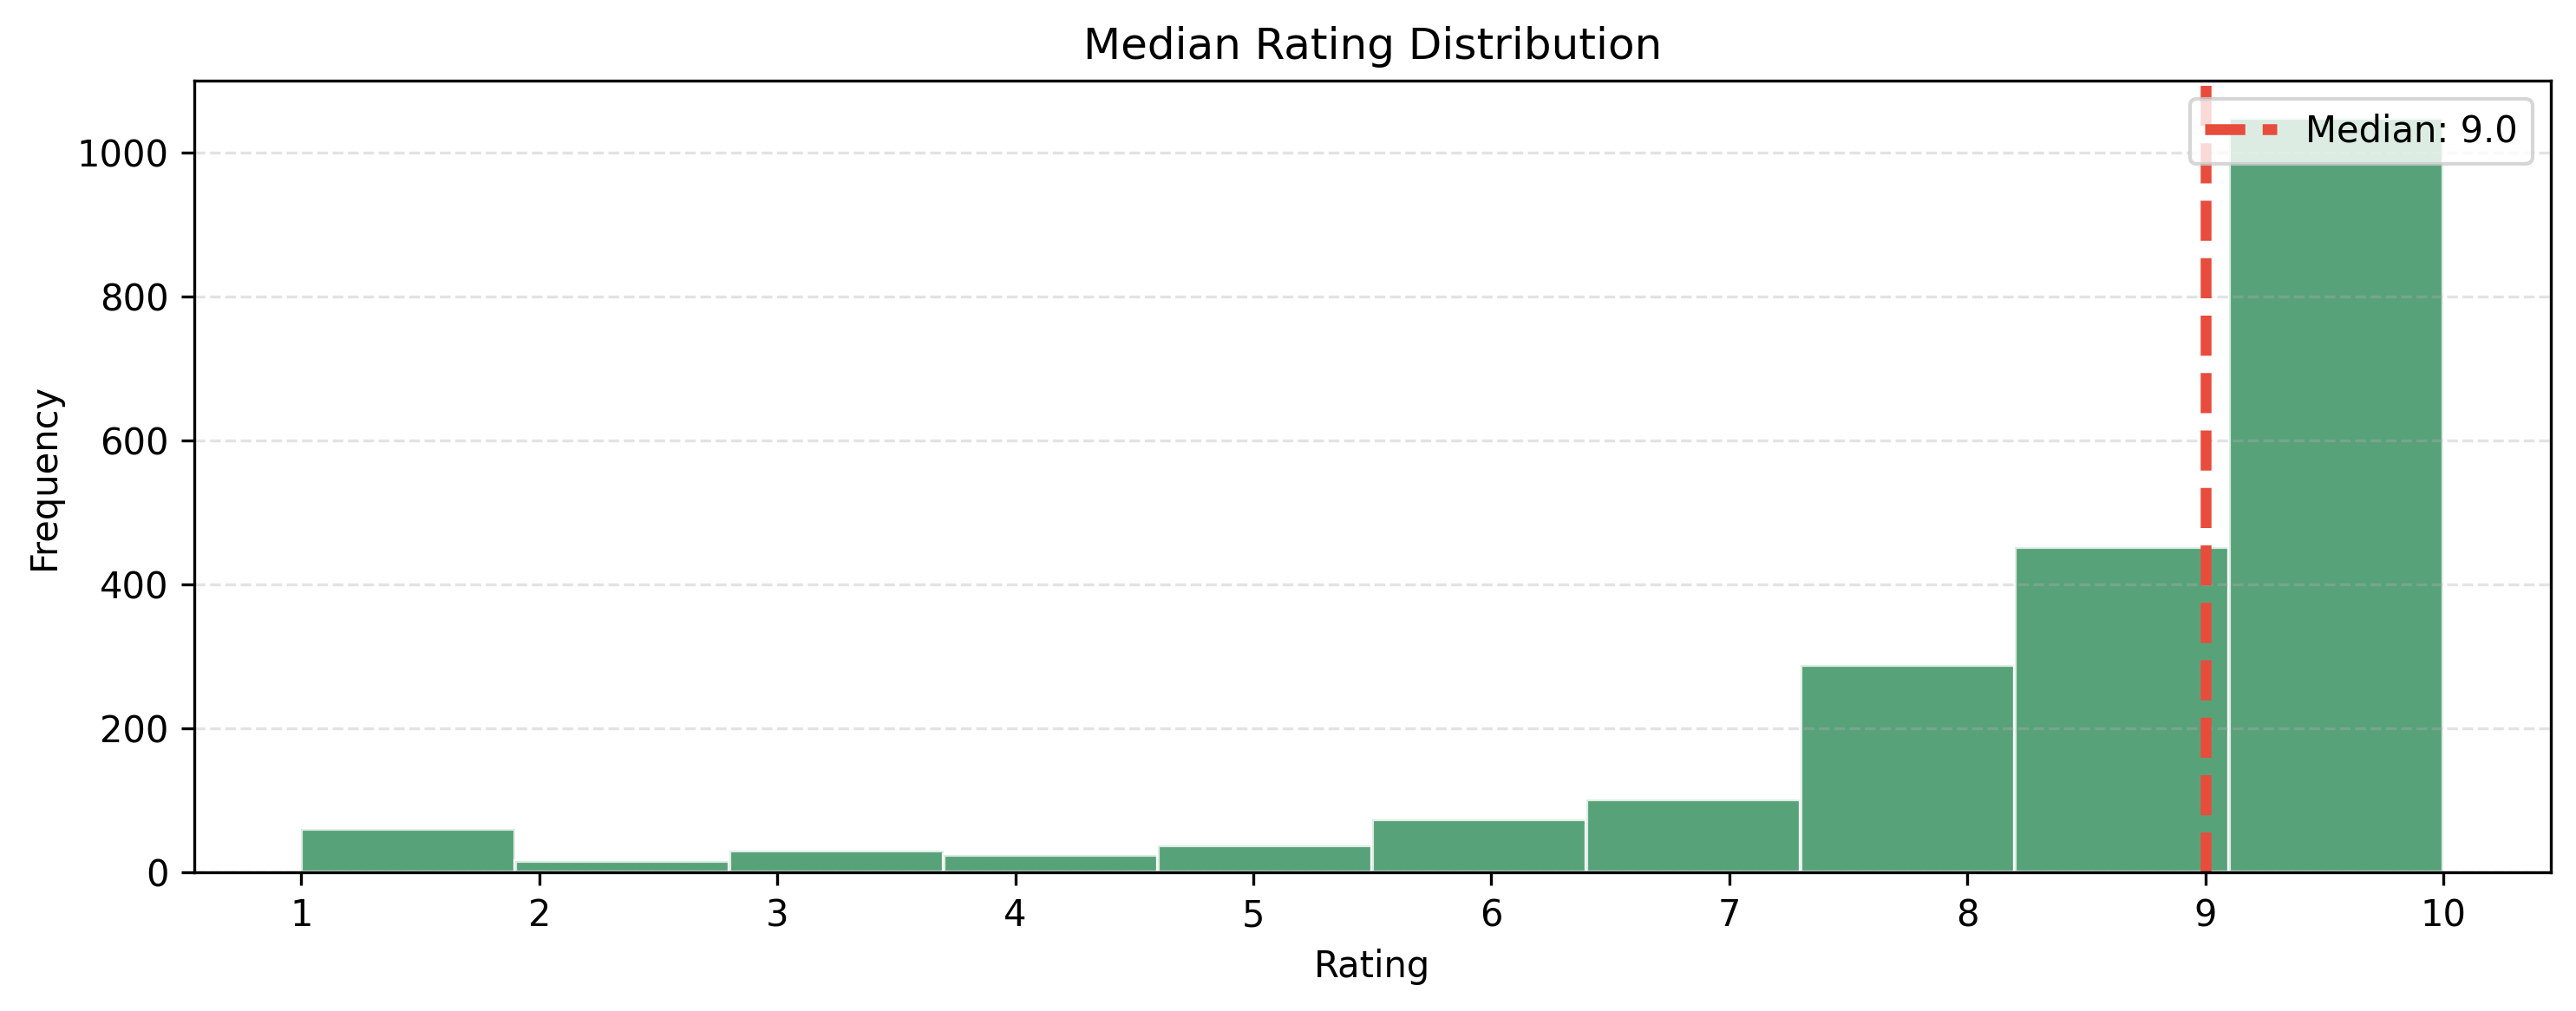

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure rating_series is available for plotting
if 'rating_series' not in globals():
    if 'analysis_df' in globals():
        rating_series = analysis_df['Rating']
    elif 'df_clean' in globals():
        rating_series = df_clean['Rating']
    elif 'df_raw' in globals():
        df_clean = df_raw.copy()
        df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
        df_clean = df_clean.dropna(subset=['Rating'])
        df_clean = df_clean[df_clean['Rating'].between(1, 10)]
        rating_series = df_clean['Rating']
    else:
        try:
            DATA_PATH = '3_idiots_reviews.csv'
            df_raw = pd.read_csv(DATA_PATH)
            df_clean = df_raw.copy()
            df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
            df_clean = df_clean.dropna(subset=['Rating'])
            df_clean = df_clean[df_clean['Rating'].between(1, 10)]
            rating_series = df_clean['Rating']
        except Exception as exc:
            raise NameError('rating_series is not defined and cannot be initialized without analysis_df, df_clean, df_raw, or data file') from exc

rating_series = pd.to_numeric(rating_series, errors='coerce').dropna()
if rating_series.empty:
    raise ValueError('No valid numeric ratings available to generate the median graph.')
median_rating = float(rating_series.median())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rating_series, bins=10, color='#2E8B57', edgecolor='white', alpha=0.8)
ax.axvline(median_rating, color='#E74C3C', linestyle='--', linewidth=3, label=f'Median: {median_rating:.1f}')
ax.set_title('Median Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.set_xticks(sorted(set(list(range(int(rating_series.min()), int(rating_series.max()) + 1)) + [int(round(median_rating))])))
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.35)
fig.tight_layout()
median_img_path = 'median_rating_graph.png'
fig.savefig(median_img_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved median rating graph to', median_img_path)
display(Image(median_img_path))

## Mode Analysis

The mode identifies the most frequently observed rating and reflects the dominant audience opinion. It is useful for highlighting the most common score.

i

Mode rating(s): 10.0
The modal rating identifies the dominant audience perception and reveals the score most reviewers selected.


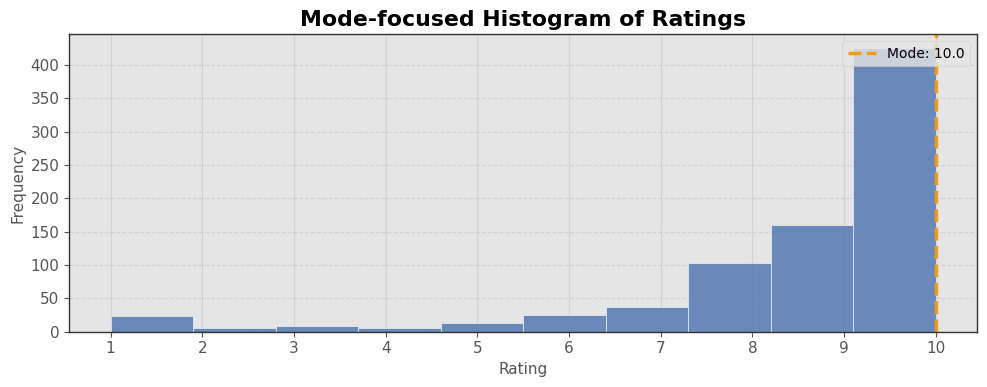

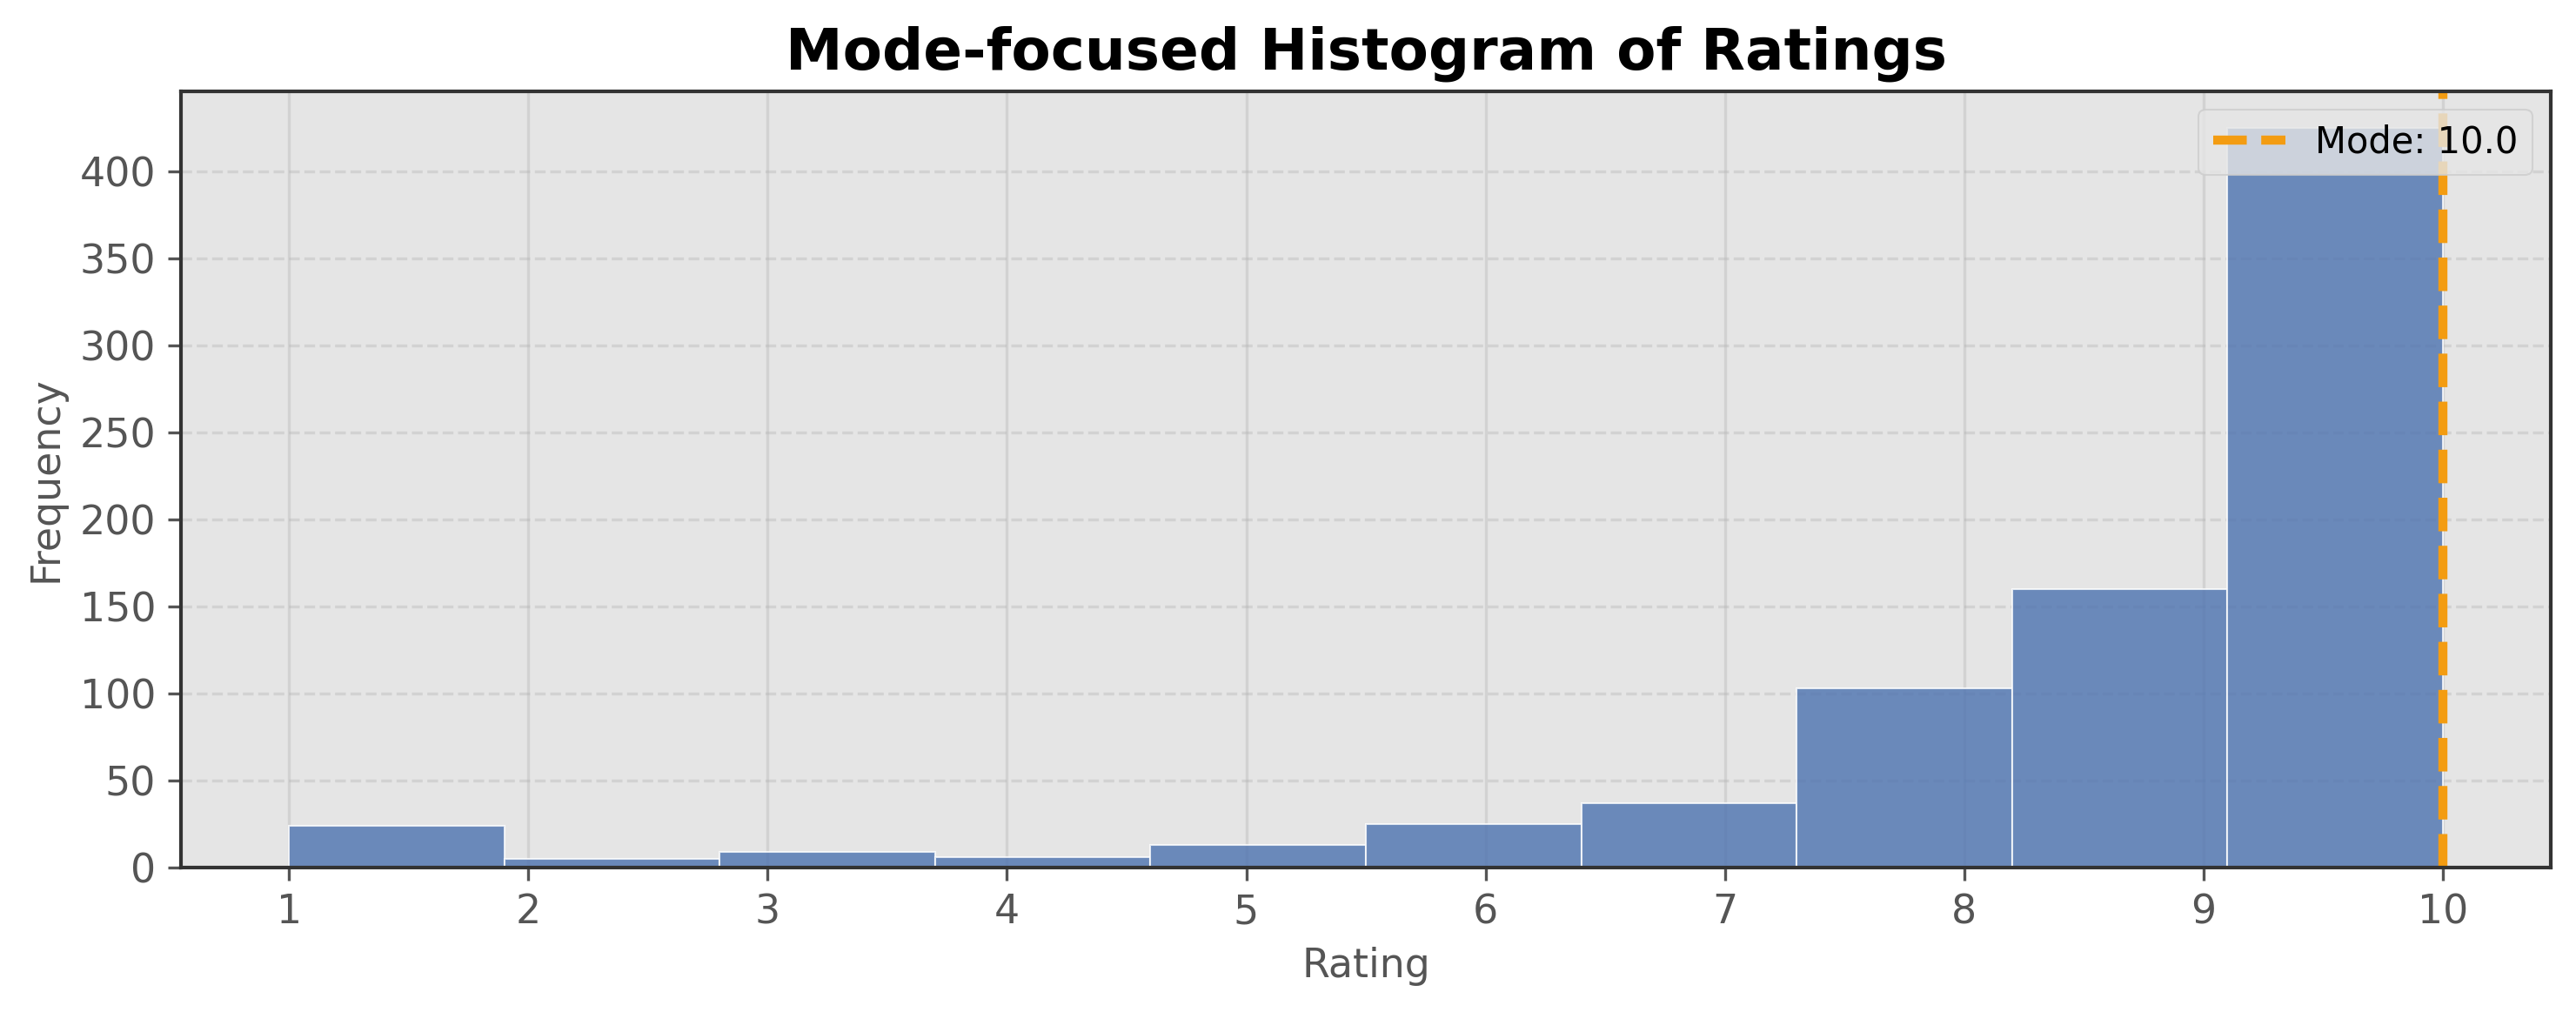

In [27]:
# Compute and display mode(s) for the Rating column
if 'rating_series' not in globals():
    if 'analysis_df' in globals():
        rating_series = analysis_df['Rating']
    elif 'df_clean' in globals():
        rating_series = df_clean['Rating']
    else:
        raise NameError('rating_series is not defined and cannot be initialized without analysis_df or df_clean')
# Ensure numeric series
rating_series = pd.to_numeric(rating_series, errors='coerce').dropna()
if rating_series.empty:
    print('No valid numeric ratings available to compute mode.')
else:
    mode_values = rating_series.mode()
    # Present modes as a comma-separated list
    mode_rating = ', '.join([str(v) for v in mode_values.tolist()])
    print(f'Mode rating(s): {mode_rating}')
    print('The modal rating identifies the dominant audience perception and reveals the score most reviewers selected.')
    # Create and save a mode-focused histogram image
    import matplotlib.pyplot as plt
    from IPython.display import Image, display
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(rating_series, bins=10, color='#4C72B0', edgecolor='white', alpha=0.8)
    # Draw vertical lines for each mode value
    for m in mode_values.tolist():
        ax.axvline(m, color='#F39C12', linestyle='--', linewidth=2.5, label=f'Mode: {m}')
    # If multiple modes, avoid duplicate legend entries by using unique labels
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        # keep unique labels only
        unique = {}
        for h, l in zip(handles, labels):
            unique[l] = h
        ax.legend(unique.values(), unique.keys(), loc='upper right', fontsize=10)
    ax.set_title('Mode-focused Histogram of Ratings')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Frequency')
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    img_path = 'mode_rating_graph.png'
    fig.tight_layout()
    fig.savefig(img_path, dpi=300, bbox_inches='tight')
    plt.show()
    # Display saved image explicitly (attachment-like)
    display(Image(img_path))

## Range Analysis

Range measures the full span of ratings and describes diversity of opinion.
$$\text{Range} = \text{Maximum} - \text{Minimum}$$


In [9]:
rating_range = rating_series.max() - rating_series.min()
print(f'Rating range: {rating_range:.3f} (max {rating_series.max():.1f}, min {rating_series.min():.1f})')
print('Interpretation: The range describes audience agreement and the diversity of opinion. A wider range implies that responses vary significantly across the sample.')


Rating range: 9.000 (max 10.0, min 1.0)
Interpretation: The range describes audience agreement and the diversity of opinion. A wider range implies that responses vary significantly across the sample.


## Standard Deviation Analysis

Standard deviation quantifies the typical deviation from the mean and reflects variability in audience ratings.
$$\sigma = \sqrt{\frac{\sum (x-\bar{x})^2}{n}}$$


In [10]:
std_dev = rating_series.std(ddof=0)
print(f'Standard deviation: {std_dev:.3f}')
print('Interpretation: Standard deviation indicates whether audience opinion is stable or dispersed. A lower value suggests consistent sentiment, while a higher value suggests the movie may be more controversial.')


Standard deviation: 2.028
Interpretation: Standard deviation indicates whether audience opinion is stable or dispersed. A lower value suggests consistent sentiment, while a higher value suggests the movie may be more controversial.


## Variance Analysis

Variance is the square of the standard deviation and describes spread in squared units. It provides additional insight into dispersion.


In [11]:
variance_value = rating_series.var(ddof=0)
print(f'Variance: {variance_value:.3f}')
print('Interpretation: Variance quantifies the spread of audience ratings around the mean. Higher variance indicates broader dispersion in public perception.')


Variance: 4.113
Interpretation: Variance quantifies the spread of audience ratings around the mean. Higher variance indicates broader dispersion in public perception.


## Skewness Analysis

Skewness measures asymmetry in the rating distribution. Positive skew means a longer right-hand tail; negative skew means a longer left-hand tail.
$$\text{Skewness} = \frac{\sum (x-\bar{x})^3}{n\sigma^3}$$


In [12]:
skewness_value = stats.skew(rating_series, bias=False) if stats is not None else np.nan
print(f'Skewness: {skewness_value:.3f}')
if np.isnan(skewness_value):
    print('Skewness could not be calculated.')
elif skewness_value > 0:
    print('Interpretation: Positive skew indicates that lower scores are more frequent, with a right tail of higher ratings.')
elif skewness_value < 0:
    print('Interpretation: Negative skew indicates that higher ratings are more frequent, with a left tail of lower scores.')
else:
    print('Interpretation: The distribution is approximately symmetric.')


Skewness: -2.355
Interpretation: Negative skew indicates that higher ratings are more frequent, with a left tail of lower scores.


In [13]:
interval_labels = ['1-2', '3-4', '5-6', '7-8', '9-10']
analysis_df['Rating Interval'] = pd.cut(analysis_df['Rating'], bins=[0.5, 2.5, 4.5, 6.5, 8.5, 10.5], labels=interval_labels, right=True)
frequency_table = analysis_df['Rating Interval'].value_counts().sort_index().rename_axis('Rating Interval').reset_index(name='Frequency')
print('Rating frequency distribution:')
display(frequency_table)
print('Interpretation: The frequency table reveals audience concentration and identifies the dominant rating zone.')


Rating frequency distribution:


,Rating Interval,Frequency
0,1-2,29
1,3-4,15
2,5-6,38
3,7-8,140
4,9-10,585


Interpretation: The frequency table reveals audience concentration and identifies the dominant rating zone.


## Visualization Introduction

Visualizations translate numeric summaries into intuitive patterns. The following charts help validate the distribution shape, modal zones, and sentiment composition.


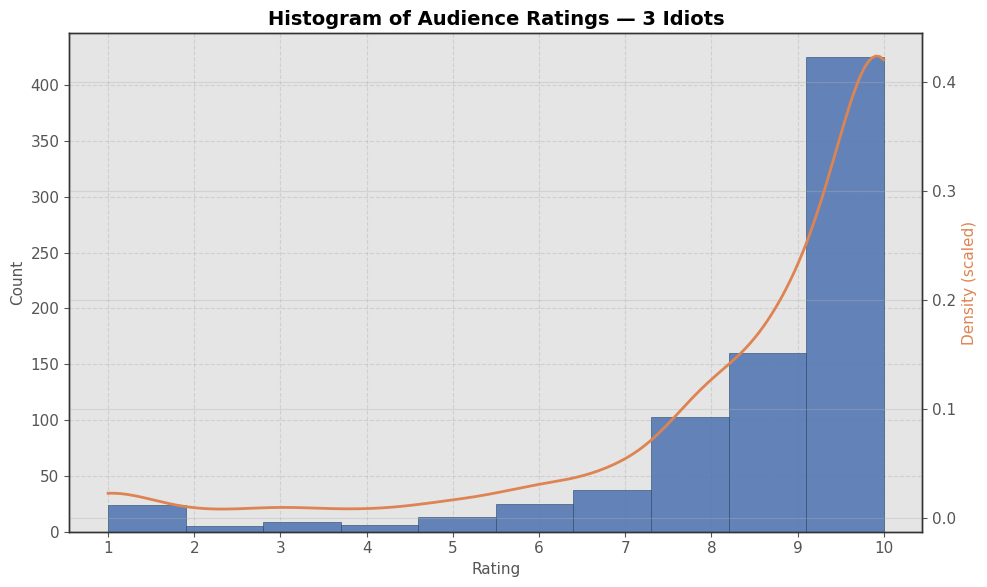

Interpretation: The histogram displays rating concentration and spread. It highlights where audience opinion clusters and whether there is pronounced skew.


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(rating_series, bins=10, color='#4C72B0', edgecolor='#2A4D69', alpha=0.85)
if stats is not None:
    kde = stats.gaussian_kde(rating_series)
    xs = np.linspace(rating_series.min(), rating_series.max(), 200)
    ax2 = ax.twinx()
    ax2.plot(xs, kde(xs), color='#DD8452', linewidth=2)
    ax2.set_ylabel('Density (scaled)', color='#DD8452')
ax.set_title('Histogram of Audience Ratings — 3 Idiots', fontsize=14)
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_xticks(range(1, 11))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('Interpretation: The histogram displays rating concentration and spread. It highlights where audience opinion clusters and whether there is pronounced skew.')


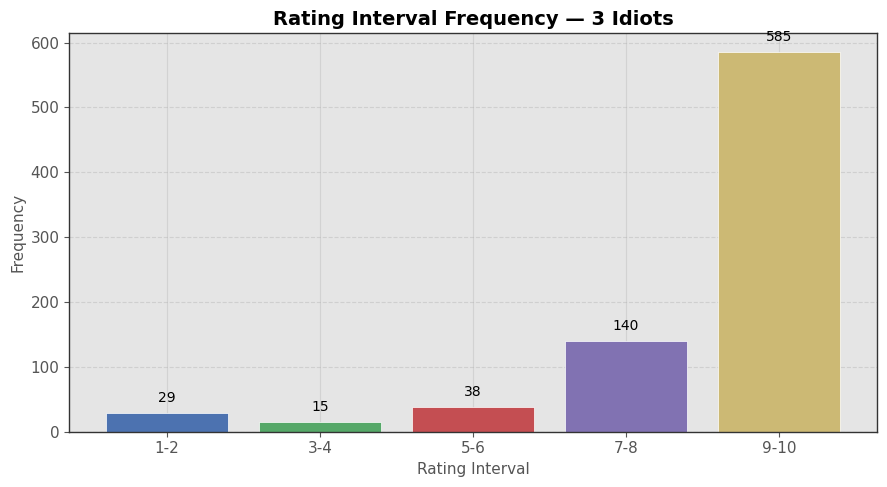

Interpretation: The bar chart identifies the most common rating interval and visualizes audience concentration across defined opinion zones.


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(frequency_table['Rating Interval'].astype(str), frequency_table['Frequency'], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'], edgecolor='white')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=10)
ax.set_title('Rating Interval Frequency — 3 Idiots', fontsize=14)
ax.set_xlabel('Rating Interval')
ax.set_ylabel('Frequency')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('Interpretation: The bar chart identifies the most common rating interval and visualizes audience concentration across defined opinion zones.')


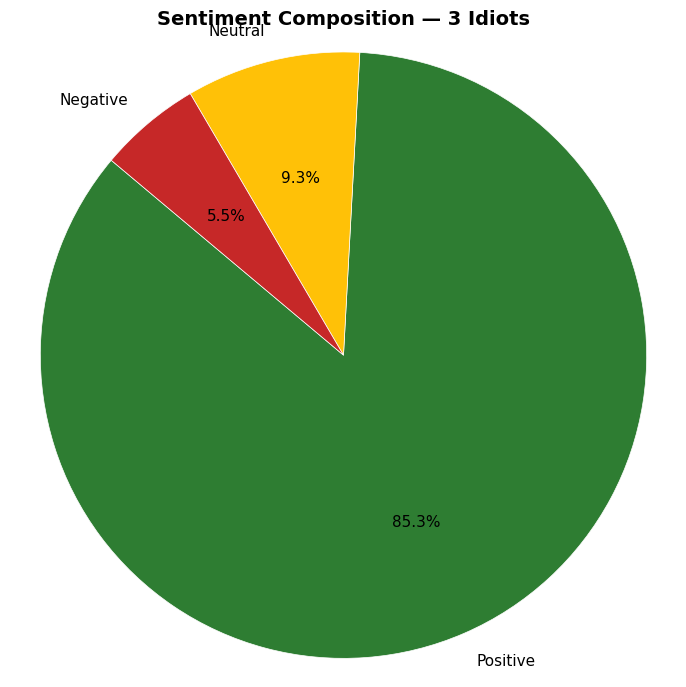

Interpretation: The pie chart shows the proportional shares of positive, neutral, and negative reviews, revealing the dominant audience sentiment.


In [17]:
sentiment_counts = analysis_df['Review Type'].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#2E7D32', '#FFC107', '#C62828'], wedgeprops={'edgecolor': 'white'})
ax.set_title('Sentiment Composition — 3 Idiots', fontsize=14)
ax.axis('equal')
plt.tight_layout()
plt.show()
print('Interpretation: The pie chart shows the proportional shares of positive, neutral, and negative reviews, revealing the dominant audience sentiment.')


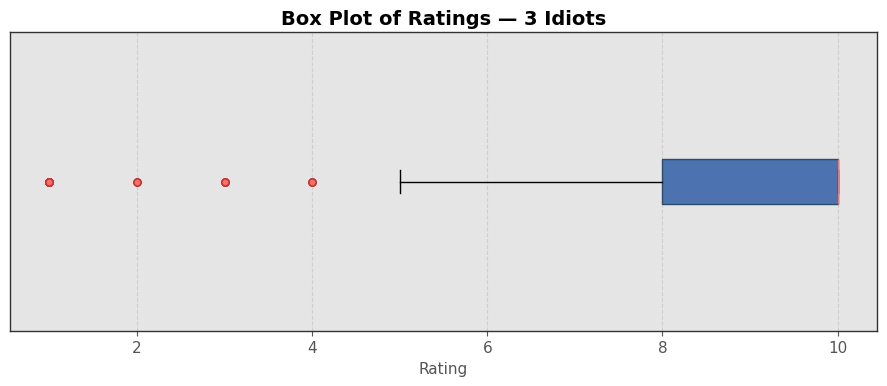

Interpretation: The box plot exposes median, quartiles, and outliers to assess rating consistency and extreme opinions.


In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(rating_series, vert=False, patch_artist=True, boxprops={'facecolor': '#4C72B0', 'edgecolor': '#2A4D69'}, medianprops={'color': '#FF6F61'}, flierprops={'marker': 'o', 'markerfacecolor': '#FF6F61', 'markeredgecolor': '#BF3B3B', 'markersize': 5})
ax.set_title('Box Plot of Ratings — 3 Idiots', fontsize=14)
ax.set_xlabel('Rating')
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('Interpretation: The box plot exposes median, quartiles, and outliers to assess rating consistency and extreme opinions.')


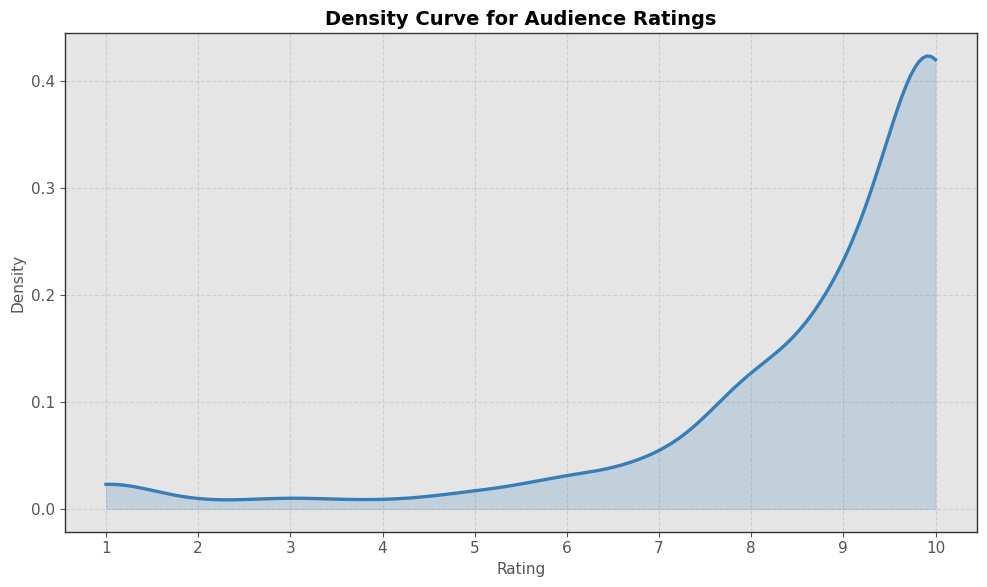

Interpretation: The density plot reveals distribution shape, skewness, and concentration trends for audience ratings.


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
x_values = np.linspace(rating_series.min(), rating_series.max(), 200)
if stats is not None:
    density = stats.gaussian_kde(rating_series)
    ax.plot(x_values, density(x_values), color='#377EB8', linewidth=2.4)
    ax.fill_between(x_values, density(x_values), color='#377EB8', alpha=0.2)
ax.set_title('Density Curve for Audience Ratings', fontsize=14)
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_xticks(range(1, 11))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print('Interpretation: The density plot reveals distribution shape, skewness, and concentration trends for audience ratings.')


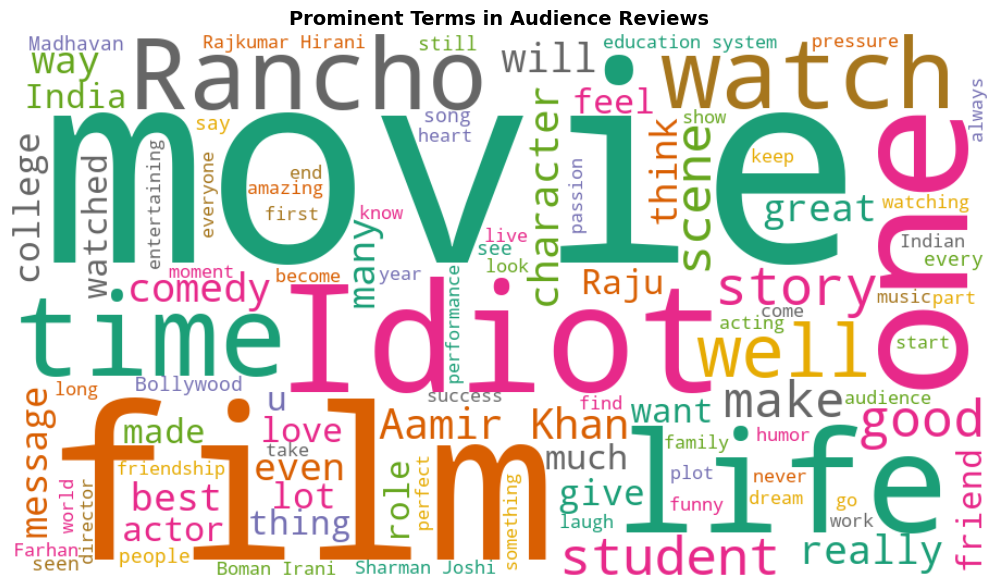

Interpretation: This word cloud identifies recurring audience terms and highlights the language that appears most frequently in reviews.


In [20]:
combined_text = ' '.join(analysis_df['Review'].dropna().astype(str).values)
if WordCloud is not None:
    wordcloud = WordCloud(width=900, height=500, background_color='white', stopwords=STOPWORDS, colormap='Dark2', max_words=100).generate(combined_text)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Prominent Terms in Audience Reviews', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('WordCloud is unavailable in the environment.')
print('Interpretation: This word cloud identifies recurring audience terms and highlights the language that appears most frequently in reviews.')


## Final Interpretation

1. **Is the movie generally liked?**  
   The rating summary and sentiment distribution indicate a generally positive audience response.
2. **Is the movie controversial?**  
   Dispersion exists, but the concentration of higher scores suggests moderate disagreement rather than widespread controversy.
3. **What does skewness indicate?**  
   Skewness measures asymmetry. A negative skew indicates that higher ratings are concentrated toward the top of the scale.
4. **Which rating interval has highest frequency?**  
   The frequency table identifies the dominant rating interval and shows where audience opinion is most concentrated.
5. **Do visual trends support statistical findings?**  
   Yes — histogram, density, and sentiment visuals align with the numeric conclusions about positive reception.


## Final Conclusion

This notebook delivers a complete statistical analysis of audience reviews for *3 Idiots*. Central tendency, dispersion, and sentiment analyses demonstrate a generally positive public reception. Visualizations confirm the distribution shape, while the text summary highlights recurring themes in audience feedback.

The analytic workflow shows how structured review data can be transformed into reliable insights for entertainment research and audience measurement.
